In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
X = 6*np.random.rand(200,1)-3
y = 0.8 * X**2 + 0.9*X+2 + np.random.randn(200,1)

# y = 0.8X^2 + 0.9X+ 2 

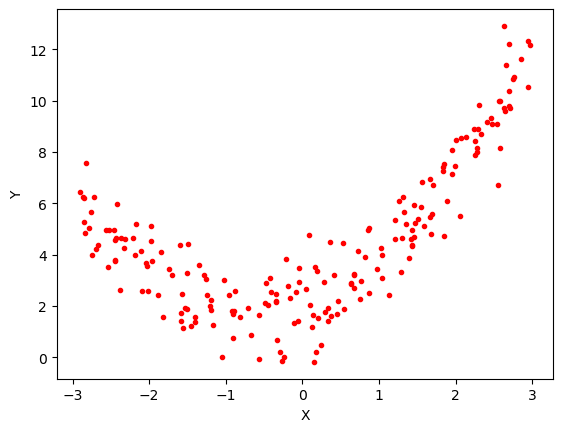

In [13]:
plt.plot(X,y,'r.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [17]:
lr = LinearRegression()

In [19]:
lr.fit(X_train,y_train)

LinearRegression()

In [21]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.20280863487425282

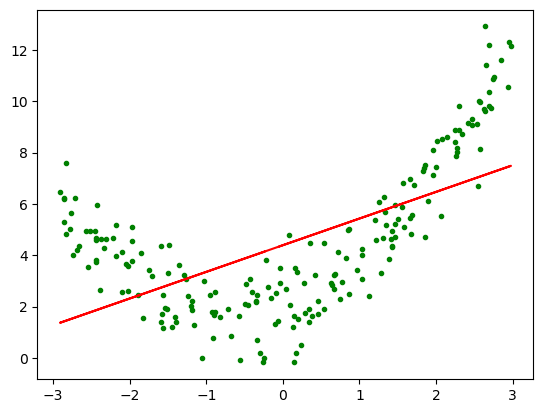

In [27]:
plt.plot(X,y,'g.')
plt.plot(X_train,lr.predict(X_train),color = 'r')
plt.show()

In [33]:
#Apply Polynomial Feature 

poly = PolynomialFeatures(degree = 2,include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [44]:
print(X_train[0])
print(X_train_trans[0])

[-0.04321474]
[ 1.         -0.04321474  0.00186751]


In [46]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [48]:
y_pred = lr.predict(X_test_trans)
r2_score(y_test,y_pred)

0.8284696811375075

In [57]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)

y_new = lr.predict(X_new_poly)

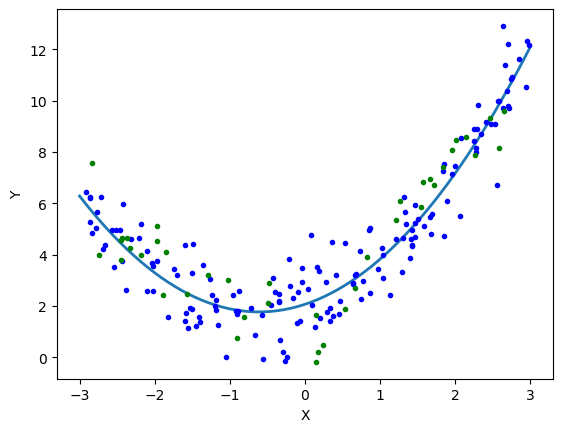

In [61]:
plt.plot(X_new,y_new,linewidth = 2,label = "Prediction")
plt.plot(X_train,y_train,'b.',label = "Training")
plt.plot(X_test,y_test,'g.',label = "Testing data")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
           